Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

Options

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

Load data

In [3]:
features = pd.read_csv("../data/civ5_features.csv")
clusters = pd.read_csv("../data/civ5_clusters.csv")
df = features.merge(clusters, on="leader_name")

cluster_labels = {
    0: "Diplomatic builders",
    1: "Scientific conquerors",
    2: "Aggressive warmongers",
    3: "Peaceful culturalists",
    4: "Wonder seekers"
}
df["cluster_name"] = df["cluster"].map(cluster_labels)

Alternative classification from the community

In [4]:
# ============================================================
# Community personality classification (Vox Populi / CivFanatics)
#
# Source: "Community Ideas: Diplomacy Flavors for AI Leaders"
# Author: Recursive (lead developer, Vox Populi Community Patch)
# URL: https://forums.civfanatics.com/threads/
#      community-ideas-diplomacy-flavors-for-ai-leaders.666737/
# Date: January 25, 2021
#
# Context: Recursive describes the existing personality system
# used in Civ 5 vanilla, which assigns each leader one of 4
# archetypes: CONQUEROR, COALITION, DIPLOMAT, EXPANSIONIST.
# These archetypes are encoded in the game's XML files and
# determine a set of diplomacy flavor values.
# This is NOT an official Firaxis classification — it is a
# community reading of the vanilla XML system, by one of the
# most technically knowledgeable members of the Civ 5 modding
# community.
#
# Note on ambiguous cases:
# - Pocatello (Shoshone): not listed explicitly; assigned
#   EXPANSIONIST based on his XML profile (EXPANSION=8, high
#   DEFENSE and GROWTH).
# - EnricoDandolo (Venice): not listed in the main personality
#   but appears in the City-State Coalition group; assigned
#   COALITION here.
# ============================================================

In [5]:
official_personality = {
    # CONQUEROR
    "Ashurbanipal":  "CONQUEROR",
    "Harald":        "CONQUEROR",
    "Attila":        "CONQUEROR",
    "OdaNobunaga":   "CONQUEROR",
    "GenghisKhan":   "CONQUEROR",
    "Napoleon":      "CONQUEROR",
    "Gustavus":      "CONQUEROR",
    "Montezuma":     "CONQUEROR",
    "Augustus":      "CONQUEROR",
    "Askia":         "CONQUEROR",
    "Shaka":         "CONQUEROR",

    # COALITION
    "Pacal":         "COALITION",
    "Sejong":        "COALITION",
    "Pachacuti":     "COALITION",
    "Elizabeth":     "COALITION",
    "MariaI":        "COALITION",
    "Casimir":       "COALITION",
    "Kamehameha":    "COALITION",
    "William":       "COALITION",
    "Isabella":      "COALITION",
    "Washington":    "COALITION",
    "EnricoDandolo": "COALITION",

    # DIPLOMAT
    "Hiawatha":      "DIPLOMAT",
    "Theodora":      "DIPLOMAT",
    "Pocatello":     "DIPLOMAT",
    "Maria":         "DIPLOMAT",
    "Pedro":         "DIPLOMAT",
    "Gandhi":        "DIPLOMAT",
    "AhmadalMansur": "DIPLOMAT",
    "Bismark":       "DIPLOMAT",
    "Ramkhamhaeng":  "DIPLOMAT",
    "Selassie":      "DIPLOMAT",

    # EXPANSIONIST
    "Boudicca":      "EXPANSIONIST",
    "HarunAlRashid": "EXPANSIONIST",
    "Nebuchadnezzar":"EXPANSIONIST",
    "Dido":          "EXPANSIONIST",
    "Alexander":     "EXPANSIONIST",
    "Catherine":     "EXPANSIONIST",
    "Ramesses":      "EXPANSIONIST",
    "WuZetian":      "EXPANSIONIST",
    "Suleiman":      "EXPANSIONIST",
    "Darius":        "EXPANSIONIST",
    "GajahMada":     "EXPANSIONIST",
}

df["official_personality"] = df["leader_name"].map(official_personality)

missing = df[df["official_personality"].isna()]["leader_name"].tolist()
print(f"Leaders without personality assigned: {missing}")
print(f"Coverage: {df['official_personality'].notna().sum()}/{len(df)}")

Leaders without personality assigned: []
Coverage: 43/43


Contingency table: clusters vs community personality

In [6]:
contingency = pd.crosstab(
    df["cluster_name"],
    df["official_personality"],
    margins=True
)
print("\nContingency table (K-means clusters vs Vox Populi personality):")
print(contingency)


Contingency table (K-means clusters vs Vox Populi personality):
official_personality   COALITION  CONQUEROR  DIPLOMAT  EXPANSIONIST  All
cluster_name                                                            
Aggressive warmongers          1          7         0             2   10
Diplomatic builders            6          1         2             0    9
Peaceful culturalists          0          0         6             0    6
Scientific conquerors          0          3         1             3    7
Wonder seekers                 4          0         1             6   11
All                           11         11        10            11   43


Cramér's V — association strength

In [7]:
ct = pd.crosstab(df["cluster_name"], df["official_personality"])
chi2, p, dof, expected = chi2_contingency(ct)
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

print(f"\nChi² = {chi2:.2f}, p = {p:.4f}, dof = {dof}")
print(f"Cramér's V = {cramers_v:.3f}")
print("(0 = no association, 1 = perfect association)")



Chi² = 51.43, p = 0.0000, dof = 12
Cramér's V = 0.631
(0 = no association, 1 = perfect association)


In [15]:
# Cramér's V = 0.631 → strong association (p < 0.001)
#
# Interpretation: the K-means clustering (derived purely from
# XML data, unsupervised) recovers a large share of the
# structure captured by the Vox Populi community classification.
# This validates that the 5 clusters are not arbitrary — they
# reflect personality archetypes recognized by experienced
# players.
#
# The remaining divergence (~37%) is informative: it suggests
# the K-means clustering captures additional dimensions not
# encoded in the 4-archetype VP system (e.g. the
# Science/Conquest axis that separates clusters 1 and 2).

Heatmap (row-normalized)

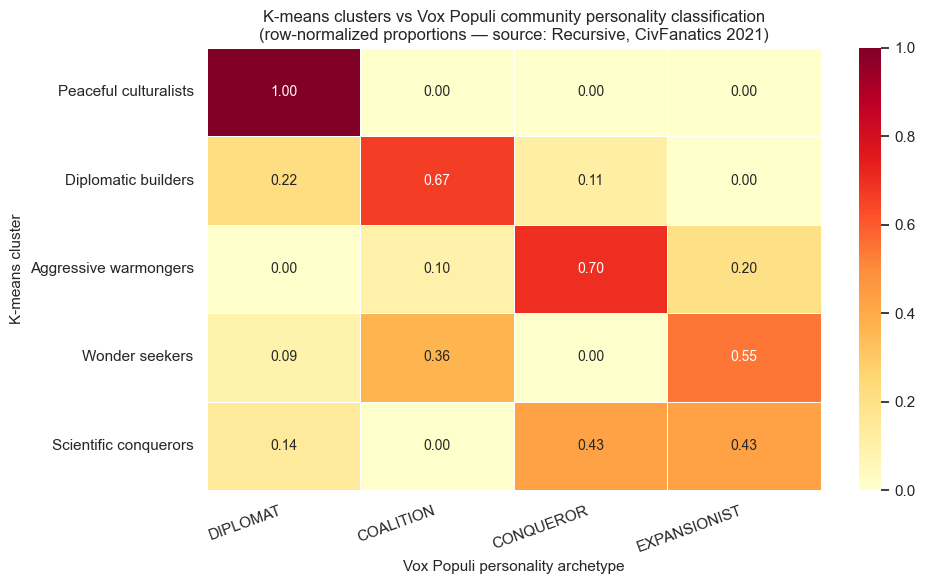

In [12]:
# Reorder rows and columns to align dominant values on diagonal
row_order = [
    "Peaceful culturalists",
    "Diplomatic builders",
    "Aggressive warmongers",
    "Wonder seekers",
    "Scientific conquerors",
]
col_order = ["DIPLOMAT", "COALITION","CONQUEROR", "EXPANSIONIST" ]

ct_norm_ordered = ct_norm.loc[row_order, col_order]

plt.figure(figsize=(10, 6))
sns.heatmap(ct_norm_ordered,
            annot=True, fmt=".2f",
            cmap="YlOrRd",
            linewidths=0.5,
            annot_kws={"size": 10})
plt.title(
    "K-means clusters vs Vox Populi community personality classification\n"
    "(row-normalized proportions — source: Recursive, CivFanatics 2021)",
    fontsize=12
)
plt.xlabel("Vox Populi personality archetype", fontsize=11)
plt.ylabel("K-means cluster", fontsize=11)
plt.xticks(rotation=20, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../figures/comparison_voxpopuli_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

Per-leader detail table

In [13]:
detail = df[["leader_name", "cluster_name", "official_personality"]].sort_values(
    ["official_personality", "cluster_name"]
)
print("\nPer-leader detail:")
print(detail.to_string(index=False))


Per-leader detail:
   leader_name          cluster_name official_personality
      Isabella Aggressive warmongers            COALITION
       Casimir   Diplomatic builders            COALITION
     Elizabeth   Diplomatic builders            COALITION
    Kamehameha   Diplomatic builders            COALITION
        MariaI   Diplomatic builders            COALITION
    Washington   Diplomatic builders            COALITION
       William   Diplomatic builders            COALITION
 EnricoDandolo        Wonder seekers            COALITION
         Pacal        Wonder seekers            COALITION
     Pachacuti        Wonder seekers            COALITION
        Sejong        Wonder seekers            COALITION
  Ashurbanipal Aggressive warmongers            CONQUEROR
         Askia Aggressive warmongers            CONQUEROR
        Attila Aggressive warmongers            CONQUEROR
   GenghisKhan Aggressive warmongers            CONQUEROR
        Harald Aggressive warmongers            CONQ

In [14]:
# Conclusion
#
# Strong overall agreement (Cramér's V = 0.631) between K-means
# and the Vox Populi community classification, validating that
# the 5 clusters reflect real personality structure.
#
# Key insights from divergences:
#
# 1. The Scientific conquerors cluster (cluster 1) is the most
#    informative divergence: VP splits these leaders between
#    CONQUEROR and EXPANSIONIST, but K-means groups them
#    together because they share a science+conquest profile
#    that neither VP category captures cleanly. This suggests
#    k=5 adds genuine granularity over the 4-archetype system.
#
# 2. Gustavus is the clearest case of VP bias: classified
#    CONQUEROR based on historical reputation, but his XML
#    profile aligns with Diplomatic builders. K-means is
#    more faithful to the data.
#
# 3. Isabella, Boudicca, Dido: VP (EXPANSIONIST) and player
#    intuition agree they don't belong with pure warmongers —
#    but their high military XML values pull them into
#    Aggressive warmongers in K-means. An "opportunistic
#    aggressor" sub-type that neither classification handles
#    perfectly.

Notable divergences

In [10]:
print("\n--- Notable divergences ---")
for _, row in df.iterrows():
    if pd.isna(row["official_personality"]):
        continue
    flag = False
    c = row["cluster_name"]
    p = row["official_personality"]
    if p == "CONQUEROR" and c not in ["Aggressive warmongers", "Scientific conquerors"]:
        flag = True
    if p == "DIPLOMAT" and c not in ["Diplomatic builders", "Peaceful culturalists"]:
        flag = True
    if p == "COALITION" and c not in ["Diplomatic builders", "Wonder seekers"]:
        flag = True
    if p == "EXPANSIONIST" and c not in ["Aggressive warmongers", "Scientific conquerors"]:
        flag = True
    if flag:
        print(f"  {row['leader_name']:20s} | Vox Populi: {p:12s} | K-means: {c}")




--- Notable divergences ---
  Bismark              | Vox Populi: DIPLOMAT     | K-means: Scientific conquerors
  Darius               | Vox Populi: EXPANSIONIST | K-means: Wonder seekers
  GajahMada            | Vox Populi: EXPANSIONIST | K-means: Wonder seekers
  Gustavus             | Vox Populi: CONQUEROR    | K-means: Diplomatic builders
  HarunAlRashid        | Vox Populi: EXPANSIONIST | K-means: Wonder seekers
  Isabella             | Vox Populi: COALITION    | K-means: Aggressive warmongers
  Nebuchadnezzar       | Vox Populi: EXPANSIONIST | K-means: Wonder seekers
  Ramesses             | Vox Populi: EXPANSIONIST | K-means: Wonder seekers
  Theodora             | Vox Populi: DIPLOMAT     | K-means: Wonder seekers
  WuZetian             | Vox Populi: EXPANSIONIST | K-means: Wonder seekers
